In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies  = pd.read_csv("ml-latest-small/movies.csv")
links   = pd.read_csv("ml-latest-small/links.csv")


In [3]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [5]:
df = pd.merge(ratings, movies, on="movieId")

df = df[["userId", "movieId", "rating", "timestamp", "title", "genres"]]

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [6]:
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27.368469248
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44.500000
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.618491,35530.987199,1.042529,NaN


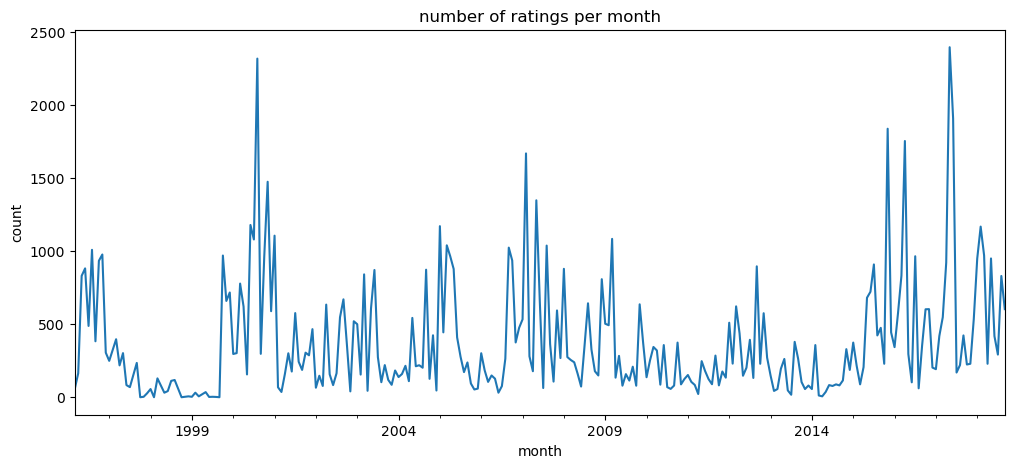

In [9]:
df["year_month"] = df["timestamp"].dt.to_period("M")

ratings_per_month = df.groupby("year_month").size()

plt.figure(figsize=(12,5))
ratings_per_month.plot()

plt.title("number of ratings per month")
plt.xlabel("month")
plt.ylabel("count")

plt.show()

In [10]:
movie_rating_count = df.groupby(["movieId", "title"]).size().reset_index(name="movie_rating_count")
movie_rating_count.sort_values("movie_rating_count", ascending=False).head(10)

,movieId,title,movie_rating_count
314,356,Forrest Gump (1994),329
277,318,"Shawshank Redemption, The (1994)",317
257,296,Pulp Fiction (1994),307
510,593,"Silence of the Lambs, The (1991)",279
1938,2571,"Matrix, The (1999)",278
224,260,Star Wars: Episode IV - A New Hope (1977),251
418,480,Jurassic Park (1993),238
97,110,Braveheart (1995),237
507,589,Terminator 2: Judgment Day (1991),224
461,527,Schindler's List (1993),220


In [11]:
df["is_like"] = (df["rating"] >= 4.0).astype(int)

movie_like = df.groupby(["movieId", "title"]).agg(
    movie_rating_count=("rating", "size"),
    like_count=("is_like", "sum")
).reset_index()

movie_like["movie_like_rate"] = movie_like["like_count"] / movie_like["movie_rating_count"]

movie_like_40 = movie_like[movie_like["movie_rating_count"] >= 40].copy()

movie_like_40.sort_values("movie_like_rate", ascending=False).head(10)[
    ["movieId", "title", "movie_rating_count", "movie_like_rate"]
]

,movieId,title,movie_rating_count,movie_like_rate
277,318,"Shawshank Redemption, The (1994)",317,0.864353
904,1203,12 Angry Men (1957),57,0.859649
974,1276,Cool Hand Luke (1967),57,0.842105
6298,48516,"Departed, The (2006)",107,0.841121
921,1221,"Godfather: Part II, The (1974)",129,0.829457
940,1242,Glory (1989),41,0.829268
659,858,"Godfather, The (1972)",192,0.822917
2224,2959,Fight Club (1999),218,0.821101
913,1213,Goodfellas (1990),126,0.817460
899,1198,Raiders of the Lost Ark (Indiana Jones and the...,200,0.815000


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
movie_like_40["popularity_norm"] = scaler.fit_transform(movie_like_40[["movie_rating_count"]])

movie_like_40.sort_values("popularity_norm", ascending=False).head(10)[
    ["movieId", "title", "movie_rating_count", "popularity_norm"]
]

,movieId,title,movie_rating_count,popularity_norm
314,356,Forrest Gump (1994),329,1.000000
277,318,"Shawshank Redemption, The (1994)",317,0.958478
257,296,Pulp Fiction (1994),307,0.923875
510,593,"Silence of the Lambs, The (1991)",279,0.826990
1938,2571,"Matrix, The (1999)",278,0.823529
224,260,Star Wars: Episode IV - A New Hope (1977),251,0.730104
418,480,Jurassic Park (1993),238,0.685121
97,110,Braveheart (1995),237,0.681661
507,589,Terminator 2: Judgment Day (1991),224,0.636678
461,527,Schindler's List (1993),220,0.622837


In [13]:
genre_df = df[["movieId", "genres"]].copy()
genre_df["genres"] = genre_df["genres"].str.split("|")
genre_df = genre_df.explode("genres")
genre_df = genre_df[genre_df["genres"] != "(no genres listed)"].copy()

genre_rating_count = genre_df.groupby("genres").size().reset_index(name="genre_rating_count")
genre_rating_count.sort_values("genre_rating_count", ascending=False).head(10)

,genres,genre_rating_count
7,Drama,41928
4,Comedy,39053
0,Action,30635
16,Thriller,26452
1,Adventure,24161
14,Romance,18124
15,Sci-Fi,17243
5,Crime,16681
8,Fantasy,11834
3,Children,9208


In [14]:
genre_rating_count = (
    genre_df.groupby("genres")
    .size()
    .reset_index(name="genre_rating_count")
)

In [15]:
genre_rating_count.sort_values(
    "genre_rating_count",
    ascending=False
).head(10)

,genres,genre_rating_count
7,Drama,41928
4,Comedy,39053
0,Action,30635
16,Thriller,26452
1,Adventure,24161
14,Romance,18124
15,Sci-Fi,17243
5,Crime,16681
8,Fantasy,11834
3,Children,9208


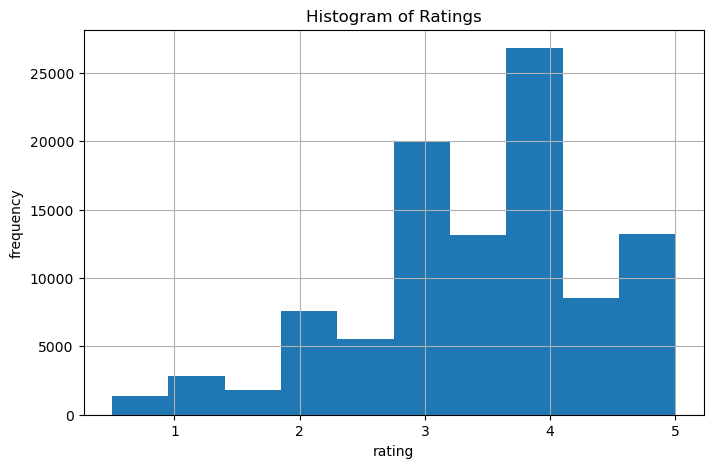

In [16]:
plt.figure(figsize=(8,5))
df["rating"].hist(bins=10)
plt.title("Histogram of Ratings")
plt.xlabel("rating")
plt.ylabel("frequency")
plt.show()

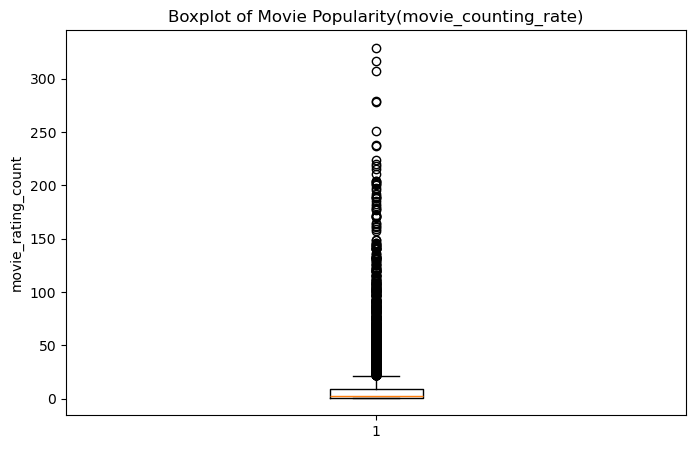

In [17]:
plt.figure(figsize=(8,5))
plt.boxplot(movie_rating_count["movie_rating_count"], vert=True)
plt.title("Boxplot of Movie Popularity(movie_counting_rate)")
plt.ylabel("movie_rating_count")
plt.show()

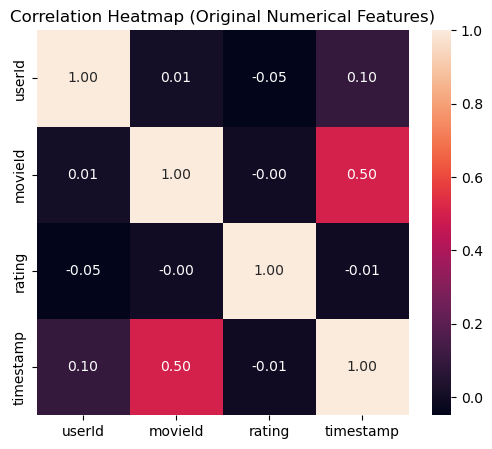

In [18]:
num_df = ratings[["userId", "movieId", "rating", "timestamp"]].copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Original Numerical Features)")
plt.show()

In [19]:
movie_feat = df.groupby(["movieId","title"]).agg(
    movie_mean_rating=("rating","mean"),
    movie_rating_count=("rating","size"),
    like_count=("is_like","sum") if "is_like" in df.columns else ("rating", lambda x: (x>=4.0).sum())
).reset_index()

movie_feat["movie_like_rate"] = movie_feat["like_count"] / movie_feat["movie_rating_count"]
movie_feat.head()

,movieId,title,movie_mean_rating,movie_rating_count,like_count,movie_like_rate
0,1,Toy Story (1995),3.920930,215,147,0.683721
1,2,Jumanji (1995),3.431818,110,50,0.454545
2,3,Grumpier Old Men (1995),3.259615,52,18,0.346154
3,4,Waiting to Exhale (1995),2.357143,7,0,0.000000
4,5,Father of the Bride Part II (1995),3.071429,49,12,0.244898


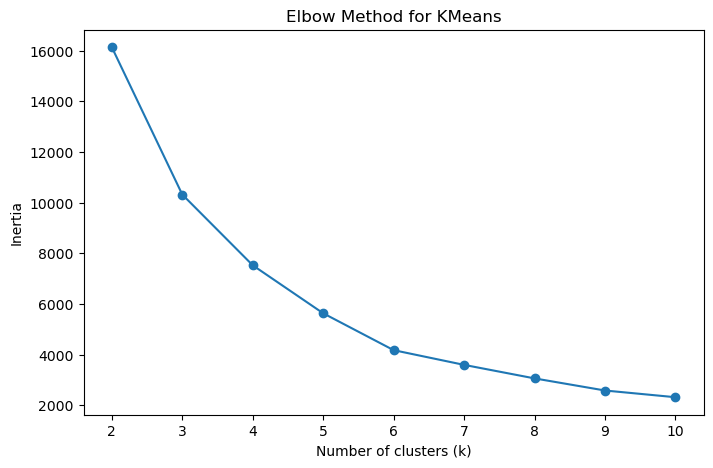

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_cluster = movie_feat[["movie_mean_rating","movie_rating_count","movie_like_rate"]].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)

inertias = []
ks = list(range(2, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [21]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
movie_feat["cluster"] = kmeans.fit_predict(X_scaled)

movie_feat["cluster"].value_counts().sort_index()

cluster
0    2149
1    2851
2     445
3    4279
Name: count, dtype: int64

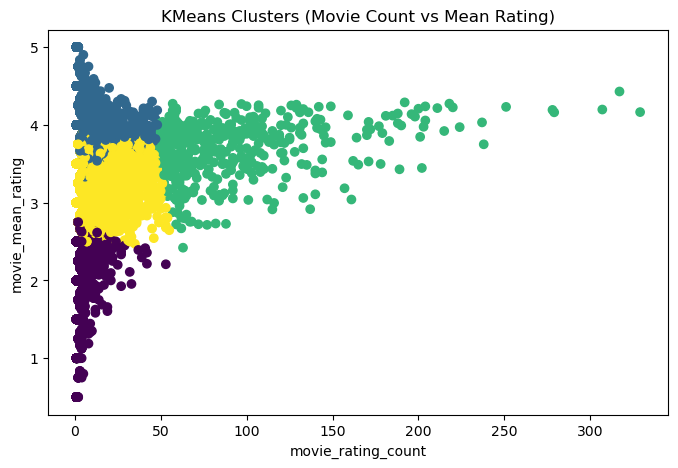

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(movie_feat["movie_rating_count"], movie_feat["movie_mean_rating"], c=movie_feat["cluster"])
plt.title("KMeans Clusters (Movie Count vs Mean Rating)")
plt.xlabel("movie_rating_count")
plt.ylabel("movie_mean_rating")
plt.show()

In [23]:
movie_feat.groupby("cluster")[["movie_mean_rating","movie_rating_count","movie_like_rate"]].mean().round(4)

,movie_mean_rating,movie_rating_count,movie_like_rate
cluster,,,
0,2.0029,3.2173,0.0175
1,4.1600,5.9597,0.8635
2,3.6872,92.2899,0.5584
3,3.2528,8.3809,0.2362


In [24]:
from sklearn.model_selection import train_test_split

data = df[["userId","movieId","rating"]].copy()
data["label"] = (data["rating"] >= 4.0).astype(int)

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
train_df.shape, test_df.shape

((80668, 4), (20168, 4))

In [25]:
user_stats = train_df.groupby("userId").agg(
    user_mean_rating=("rating","mean"),
    user_rating_count=("rating","size")
).reset_index()

movie_stats = train_df.groupby("movieId").agg(
    movie_mean_rating=("rating","mean"),
    movie_rating_count=("rating","size"),
    movie_like_rate=("label","mean")
).reset_index()

train_f = train_df.merge(user_stats, on="userId", how="left").merge(movie_stats, on="movieId", how="left")
test_f  = test_df.merge(user_stats, on="userId", how="left").merge(movie_stats, on="movieId", how="left")

fill_values = {
    "user_mean_rating": train_df["rating"].mean(),
    "user_rating_count": 0,
    "movie_mean_rating": train_df["rating"].mean(),
    "movie_rating_count": 0,
    "movie_like_rate": train_df["label"].mean()
}

train_f = train_f.fillna(fill_values)
test_f  = test_f.fillna(fill_values)

features = ["user_mean_rating","user_rating_count","movie_mean_rating","movie_rating_count","movie_like_rate"]
X_train = train_f[features]
X_test  = test_f[features]
y_train_reg = train_f["rating"]
y_test_reg  = test_f["rating"]
y_train_clf = train_f["label"]
y_test_clf  = test_f["label"]

X_train.head()

,user_mean_rating,user_rating_count,movie_mean_rating,movie_rating_count,movie_like_rate
0,3.227273,374,3.321429,14,0.428571
1,4.039683,126,4.250000,4,1.000000
2,3.407311,383,3.628049,82,0.512195
3,3.683429,1044,3.509434,53,0.490566
4,3.424863,366,3.192308,26,0.384615


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
reg.fit(X_train, y_train_reg)

pred_reg = reg.predict(X_test)
mse = mean_squared_error(y_test_reg, pred_reg)
rmse = mse ** 0.5
mse, rmse

(0.8524321920532288, 0.9232725448388622)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train, y_train_clf)

pred_clf = clf.predict(X_test)

acc = accuracy_score(y_test_clf, pred_clf)
prec = precision_score(y_test_clf, pred_clf, zero_division=0)
rec = recall_score(y_test_clf, pred_clf, zero_division=0)
f1 = f1_score(y_test_clf, pred_clf, zero_division=0)

acc, prec, rec, f1

(0.6922352241174137,
 0.6772126144455748,
 0.6869260138272624,
 0.6820347318272629)